In [ ]:
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import emcee
import ultranest

In [35]:
# 1. Le larghezze esatte derivate dalla stringa Fortran
widths = [1, 3, 5, 5, 5, 1, 3, 4, 1, 14, 12, 13, 1, 10, 1, 2, 13, 11, 1, 3, 1, 13, 12]

nomi_colonne = [
    'cc', 'NZ', 'N', 'Z', 'A', 'skip_1', 'el', 'o', 'skip_2', 
    'mass_excess', 'mass_unc', 'binding', 'skip_3', 'binding_unc', 'skip_4', 
    'B', 'beta_decay', 'beta_unc', 'skip_5', 'atomic_mass_int', 'skip_6', 
    'atomic_mass_dec', 'atomic_mass_unc'
]

# 2. Leggiamo il file (skiprows=39 dovrebbe saltare esattamente tutta l'intestazione testuale)
df = pd.read_fwf('mass_1.mas20.txt', widths=widths, names=nomi_colonne, skiprows=38)

# Rimuoviamo le colonne vuote usate come separatori
df = df.drop(columns=[col for col in df.columns if 'skip' in col])

# se ho il # alla fine del numero in BE, significa che è un numero approssimato, quindi elimino la riga
df = df.replace(r'(\d+)#', np.nan, regex=True)

# 4. Sostituiamo gli asterischi '*' con NaN (Not a Number, lo standard per i dati mancanti)
df = df.replace(r'^\s*\*\s*$', np.nan, regex=True)

df = df.dropna(subset=['binding'])

# 5. Forziamo la conversione in numeri decimali (float) per le colonne che contenevano valori
colonne_numeriche = [
    'mass_excess', 'mass_unc', 'binding', 'binding_unc', 
    'beta_decay', 'beta_unc', 'atomic_mass_dec', 'atomic_mass_unc'
]

for col in colonne_numeriche:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Risultato finale
print(df.head())

    cc  NZ  N  Z  A  el    o   mass_excess    mass_unc     binding  \
0  0.0   0  1  1  2   H  NaN  13135.722895    0.000015  1112.28310   
1  0.0   1  2  1  3   H  NaN  14949.810900    0.000080  2827.26540   
2  NaN  -1  1  2  3  He  NaN  14931.218880    0.000060  2572.68044   
4  0.0   2  3  1  4   H   -n  24621.129000  100.000000  1720.44910   
5  NaN   0  2  2  4  He  NaN   2424.915870    0.000150  7073.91560   

   binding_unc   B   beta_decay   beta_unc  atomic_mass_int  atomic_mass_dec  \
0      0.00020  B-          NaN        NaN                2     14101.777844   
1      0.00030  B-     18.59202    0.00006                3     16049.281320   
2      0.00015  B-          NaN        NaN                3     16029.321970   
4     25.00000  B-  22196.21310  100.00000                4     26431.867000   
5      0.00020  B- -22898.27400  212.13200                4      2603.254130   

   atomic_mass_unc  
0         0.000015  
1         0.000080  
2         0.000060  
4       107.35

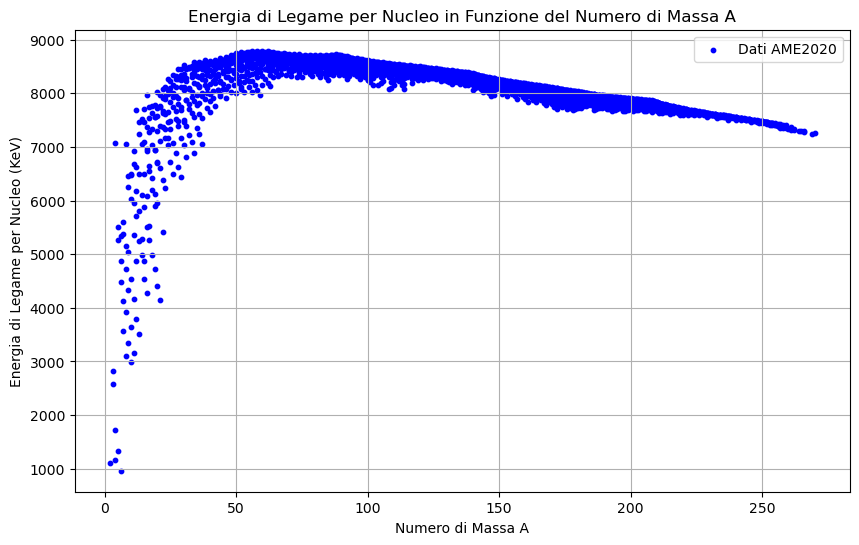

In [36]:
# grafico di BE in funzione di A
plt.figure(figsize=(10, 6))
plt.scatter(df['A'], df['binding'], s=10, color='blue', label='Dati AME2020')
plt.xlabel('Numero di Massa A')
plt.ylabel('Energia di Legame per Nucleo (KeV)')
plt.title('Energia di Legame per Nucleo in Funzione del Numero di Massa A')
plt.legend()
plt.grid()
plt.show()

In [41]:
# inferenza bayesiana con ultranest
def prior(cube):
    # cube è un array di valori tra 0 e 1, che dobbiamo trasformare nei nostri parametri
    a = cube[0] * 40  # a tra 0 e 40 (16)
    b = cube[1] * 40  # b tra 0 e 40 (17)
    c = cube[2] * 2  # c tra 0 e 2 (0.7)
    d = cube[3] * 40  # d tra 0 e 40 (23)
    return [a, b, c, d]

def model(A, Z, N, a, b, c, d):
    return a * A - b * A**(2/3) - c*(Z* (Z - 1) / (A**(1/3))) - d * (N-Z)**2 / A

def log_likelihood(params):
    a, b, c, d = params
    A = df['A'].values
    Z = df['Z'].values
    N = df['N'].values
    BE_obs = df['binding'].values /1000  # Convertiamo da KeV a MeV
    BE_model = model(A, Z, N, a, b, c, d)
    sigma = df['binding_unc'].values / 1000
    # Calcoliamo il log-likelihood assumendo errori gaussiani
    logL = -0.5 * np.sum(((BE_obs - BE_model) / sigma)**2 + np.log(2 * np.pi * sigma**2))
    return logL

In [42]:
#run ultranest
sampler = ultranest.ReactiveNestedSampler(['a', 'b', 'c', 'd'], log_likelihood, prior)
result = sampler.run()
print(result)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-4e+15  e+15 [-3.522e+15..-3.521e+15] | it/evals=13860/37445 eff=37.4140% N=400 
[ultranest] Likelihood function evaluations: 37445
[ultranest]   logZ = -3.52e+15 +- 3.122e+10
[ultranest] Effective samples strategy satisfied (ESS = 1.0, need >400)
[ultranest] Posterior uncertainty strategy wants to improve: -4731995044672870285312.00..-3520395649818759.00 (KL: 16872479673.35+-84872130500.15 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 16872479673.43 to 101744610173.50, need <0.5)
[ultranest]   logZ error budget: single: 0.32 bs:31222320048.15 tail:0.50 total:31222320048.15 required:<0.50
[ultranest] Widening from 1 to 800 live points before L=-5e+21...
[ultranest] parent value is -inf, so widening roots
[ultranest] Widening roots to 800 live points (have 400 already) ...
[ultranest] Sampling 400 live points from prior ...
[ultranest] Exploring (in particular: L=-inf..-3520395649818759.00) ...


/home/ele/anaconda3/lib/python3.13/site-packages/ultranest/integrator.py:1686: RuntimeWarning: invalid value encountered in divide
  p /= p.sum(axis=0).reshape((1, -1))


[ultranest] Explored until L=-4e+15  e+15 [-inf..-3.52e+15] | it/evals=27856/75085 eff=38.1203% N=800 
[ultranest] Likelihood function evaluations: 75085
[ultranest]   logZ = -3.52e+15 +- 3.129e+10
[ultranest] Effective samples strategy satisfied (ESS = 1.0, need >400)
[ultranest] Posterior uncertainty strategy wants to improve: -4731995044672870285312.00..-3520262823557948.00 (KL: 30212066447.42+-57616709631.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 641 minimum live points (dlogz from 30212066447.30 to 87828776078.00, need <0.5)
[ultranest]   logZ error budget: single: 0.26 bs:31292951564.45 tail:0.50 total:31292951564.45 required:<0.50
[ultranest] Widening roots to 641 live points (have 800 already) ...
[ultranest] Exploring (in particular: L=-4731995044672870285312.00..-3520262823557948.00) ...


/home/ele/anaconda3/lib/python3.13/site-packages/ultranest/integrator.py:1686: RuntimeWarning: invalid value encountered in divide
  p /= p.sum(axis=0).reshape((1, -1))


...

/home/ele/anaconda3/lib/python3.13/site-packages/ultranest/integrator.py:1686: RuntimeWarning: invalid value encountered in divide
  p /= p.sum(axis=0).reshape((1, -1))


/home/ele/anaconda3/lib/python3.13/site-packages/ultranest/integrator.py:2001: RuntimeWarning: invalid value encountered in sqrt
  self.region.create_ellipsoid(minvol=minvol)


[ultranest] Explored until L=-4e+15  e+15 [-4.732e+21..-3.52e+15] | it/evals=29649/82856 eff=29.5136% N=800 
[ultranest] Likelihood function evaluations: 82856
[ultranest]   logZ = -3.52e+15 +- 1.455e+10
[ultranest] Effective samples strategy satisfied (ESS = 1.0, need >400)
[ultranest] Posterior uncertainty strategy wants to improve: -4731995044672870285312.00..-3520238549840744.00 (KL: 10127586424.42+-28206669875.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 798 minimum live points (dlogz from 10127586424.50 to 38334256299.00, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:14545572266.93 tail:0.50 total:14545572266.93 required:<0.50
[ultranest] Widening from 1 to 1600 live points before L=-5e+21...
[ultranest] parent value is -inf, so widening roots
[ultranest] Widening roots to 1600 live points (have 800 already) ...
[ultranest] Sampling 800 live points from prior ...
[ultranest] Exploring (in particular: L=-inf..-3520238549840744.00) ...


/home/ele/anaconda3/lib/python3.13/site-packages/ultranest/integrator.py:1686: RuntimeWarning: invalid value encountered in divide
  p /= p.sum(axis=0).reshape((1, -1))


KeyboardInterrupt: 